# TrustGuard — Track 2: Financial Fraud Detection
**Team:** `TODO_TEAM_NAME` · NTU DLW Datathon 2026 · 3–4 Oct 2026

**Problem statement:** How can machine learning identify potentially fraudulent financial transactions while minimising unnecessary disruption to legitimate customers?

> **Notebook rules (team):** this file is owned by **Marcus** — nobody else edits it (notebooks don't merge).
> Germaine & others: develop in `src/*.py` + `notebooks/scratch_<name>.ipynb`; the owner inlines your functions here.
> The submitted notebook must run top-to-bottom in clean Google Colab with **no `src/` imports** and no API keys.

**Golden rule (Track 2 slides):** the model must **output probabilities, not just binary labels**.
Scoring: 60% model performance on a hidden private test set (PR-AUC 60% of that; F1 + Recall 40%) · 40% technical proposal.

**Portal spec (overrides the booklet where they differ):** official metric **PR-AUC**. Two different outputs — don't mix them up:
(a) **leaderboard CSVs** with columns `id,prediction` matching `sample_submission.csv` (verified 3 Oct: its row order equals `test.csv` order) → instant public score;
(b) the **prediction-only notebook** (no training cells) + trained model file(s) — sandbox-run on upload, **one upload per 2h, a failed run burns the window**. In the sandbox the test file has **no `id` column and shuffled rows**, and the notebook writes a single `prediction` column to `DATATHON_OUTPUT_PATH`;
(c) a 1-page report following `report_format.pdf`. Train with the platform's pinned versions (`pip install -r requirements-image.txt`, lightgbm 4.5.0 / sklearn 1.5.2 / numpy 2.1.3) or the saved model may not load. **This notebook is the training/analysis notebook — it is not uploaded; it's for our work and the finals booth. The upload artifact is `notebooks/prediction.ipynb`.**


## 1. Understanding the problem
Fraud is rare: **1.77%** of training transactions (353 of 20,000). A model that always predicts "not fraud" is 98.2% accurate and catches nothing, so accuracy is the wrong yardstick. We optimise **PR-AUC** (ranking quality on the rare class) and report **F1/Recall** at a business threshold. A missed fraud costs the full amount (mean fraud ≈ $571); a false alarm costs a review and customer goodwill — the brief asks us to minimise disruption to legitimate customers.

Key facts we must design around (verified in §2):
- The test set is shifted: bigger amounts, more new devices, ~3.5× more missing values, and many large purchases from **old accounts** (rarely fraud).
- The private test set "may contain different observations and edge cases" → robustness beats leaderboard-chasing.
- Output is a **probability** — our prediction notebook reads it via `predict_proba` (with a `predict` fallback for booster-style models), per the organisers' template.


In [1]:
# Setup — single cell, Colab-safe. Everything below uses only these imports.
import os, sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold, RepeatedStratifiedKFold
from sklearn.metrics import (average_precision_score, f1_score, recall_score,
                             precision_recall_curve, brier_score_loss, roc_auc_score)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier

warnings.filterwarnings("ignore", category=UserWarning)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 50)
print("python", sys.version.split()[0], "| pandas", pd.__version__, "| lightgbm", lgb.__version__)


python 3.13.2 | pandas 2.2.3 | lightgbm 4.5.0


In [2]:
# Locate the data (repo layout, Colab working dir, or raw organiser filenames).
def find_csv(names, required=True):
    roots = [Path("."), Path(".."), Path("../data/raw/track2"), Path("data/raw/track2"),
             Path("/content"), Path("/content/Track 2 Dataset")]
    for r in roots:
        for n in names:
            p = r / n
            if p.exists():
                return p
    if required:
        raise FileNotFoundError(f"Place the Track 2 CSVs next to this notebook: {names}")
    return None   # optional file (e.g. sample_submission.csv) simply absent

TRAIN_PATH = find_csv(["train.csv", "Track 2 Training Dataset.csv"])
TEST_PATH  = find_csv(["test.csv",  "Track 2 Testing Dataset.csv"])
train = pd.read_csv(TRAIN_PATH)
test  = pd.read_csv(TEST_PATH)
TARGET, ID_COL = "fraud", "id"
print(TRAIN_PATH, train.shape, "|", TEST_PATH, test.shape)


../data/raw/track2/train.csv (20000, 12) | ../data/raw/track2/test.csv (12000, 11)


## 2. Explore the dataset
**Owner: Marcus.** Four questions drive this section: *what does fraud look like, is the money material,
how does the test set differ from training, and where could the data mislead the model?*
Every chart carries a one-sentence takeaway (the comment at the end of its cell).


In [3]:
# 2a. Overview: size, types, blanks (train vs test), target balance.
print(f"train {train.shape} | test {test.shape} | fraud: {train[TARGET].sum()} of {len(train)} = {train[TARGET].mean():.2%} (~1 in {round(1/train[TARGET].mean())})")

FEAT_COLS = [c for c in test.columns if c != ID_COL]
overview = pd.DataFrame({
    "dtype": train[FEAT_COLS].dtypes.astype(str),
    "blank_train_%": (train[FEAT_COLS].isna().mean() * 100).round(2),
    "blank_test_%": (test[FEAT_COLS].isna().mean() * 100).round(2),
    "nunique_train": train[FEAT_COLS].nunique(),
})
overview
# Takeaway: fraud is rare (1.77%) and every history/context column has blanks - but test has ~3.5x
# more of them (2.0-2.4% vs 0.5-0.8%), while transaction_amount and transaction_hour are never blank.


train (20000, 12) | test (12000, 11) | fraud: 353 of 20000 = 1.76% (~1 in 57)


,dtype,blank_train_%,blank_test_%,nunique_train
transaction_amount,float64,0.00,0.00,14134
transaction_hour,int64,0.00,0.00,24
merchant_category,object,0.56,2.16,11
country,object,0.53,2.23,10
transaction_channel,object,0.62,2.37,4
transactions_last_24h,float64,0.80,2.44,27
spend_last_24h,float64,0.66,2.22,16987
account_age,float64,0.68,2.20,3366
new_device,float64,0.62,2.44,2
transactions_last_1h,float64,0.71,2.04,10


### Column glossary
The organisers gave **no data dictionary**, so the meanings below are *our reading of the column names*,
checked against the data. Every range and count in the table is computed, not typed. Where a name is
ambiguous (whose transactions? which hour? does the count include this one?), we say so rather than guess.


In [4]:
t = train
rng = lambda c: f"{t[c].min():g} - {t[c].max():g}"
n_amt_floor = int((t.transaction_amount == t.transaction_amount.min()).sum())
n_age_cap = int((t.account_age == t.account_age.max()).sum())
n_24h_one_spend = int(((t.transactions_last_24h == 1) & (t.spend_last_24h > 0)).sum())
n_1h_eq_24h = int((t.transactions_last_1h == t.transactions_last_24h).sum())

GLOSSARY = pd.DataFrame([
    ("id", "transaction identifier", f"{t[ID_COL].min()} - {t[ID_COL].max()}",
     "no signal (fraud rate flat across ID ranges); never used as a feature"),
    ("transaction_amount", "value of this transaction (currency not stated; we write $)", rng("transaction_amount"),
     f"{n_amt_floor} rows sit exactly at the minimum, which looks like a floor"),
    ("transaction_hour", "hour of day of the transaction (0 = midnight)", rng("transaction_hour"),
     "time zone not stated"),
    ("merchant_category", "type of merchant", f"{t.merchant_category.nunique()} categories", ""),
    ("country", "country code: the customer's or the merchant's is not stated", f"{t.country.nunique()} codes", ""),
    ("transaction_channel", "how it was made: card present, e-commerce, mobile app, bank transfer",
     f"{t.transaction_channel.nunique()} channels", ""),
    ("transactions_last_1h", "number of transactions on the same account in the last hour (entity not stated)",
     rng("transactions_last_1h"), "see counting note below"),
    ("transactions_last_24h", "same, over the last 24 hours", rng("transactions_last_24h"), "see counting note below"),
    ("spend_last_24h", "total spent on the account in the last 24 hours", rng("spend_last_24h"),
     f"{n_24h_one_spend} rows show 1 transaction in 24h but spend above 0"),
    ("account_age", "age of the account, in days (inferred from the range)", rng("account_age"),
     f"{n_age_cap} rows sit exactly at the maximum, so ages appear capped"),
    ("new_device", "1 = made from a device not seen before on this account", "0 / 1", ""),
    (TARGET, "the label: 1 = fraudulent", "0 / 1", f"{t[TARGET].mean():.2%} of rows are fraud"),
], columns=["column", "meaning (our reading)", "range in train", "notes"])
with pd.option_context("display.max_colwidth", None):
    display(GLOSSARY)

print(f"Counting note: transactions_last_1h goes down to {t.transactions_last_1h.min():g}, but transactions_last_24h "
      f"never goes below {t.transactions_last_24h.min():g}, which suggests only the 24h count includes this transaction. "
      f"Yet {n_1h_eq_24h} rows have equal counts, which that reading forbids. The definitions look inconsistent, "
      f"so we don't claim either way.")
# Takeaway: the ambiguity doesn't hurt the model, since both sets come from the same source and
# the columns mean the same thing in train and test. It only limits how precisely we can describe them.


,column,meaning (our reading),range in train,notes
0,id,transaction identifier,FR000001 - FR020000,no signal (fraud rate flat across ID ranges); never used as a feature
1,transaction_amount,value of this transaction (currency not stated; we write $),2.5 - 9000,"23 rows sit exactly at the minimum, which looks like a floor"
2,transaction_hour,hour of day of the transaction (0 = midnight),0 - 23,time zone not stated
3,merchant_category,type of merchant,11 categories,
4,country,country code: the customer's or the merchant's is not stated,10 codes,
5,transaction_channel,"how it was made: card present, e-commerce, mobile app, bank transfer",4 channels,
6,transactions_last_1h,number of transactions on the same account in the last hour (entity not stated),0 - 9,see counting note below
7,transactions_last_24h,"same, over the last 24 hours",1 - 27,see counting note below
8,spend_last_24h,total spent on the account in the last 24 hours,0 - 15670.3,234 rows show 1 transaction in 24h but spend above 0
9,account_age,"age of the account, in days (inferred from the range)",5 - 4000,"354 rows sit exactly at the maximum, so ages appear capped"


Counting note: transactions_last_1h goes down to 0, but transactions_last_24h never goes below 1, which suggests only the 24h count includes this transaction. Yet 286 rows have equal counts, which that reading forbids. The definitions look inconsistent, so we don't claim either way.


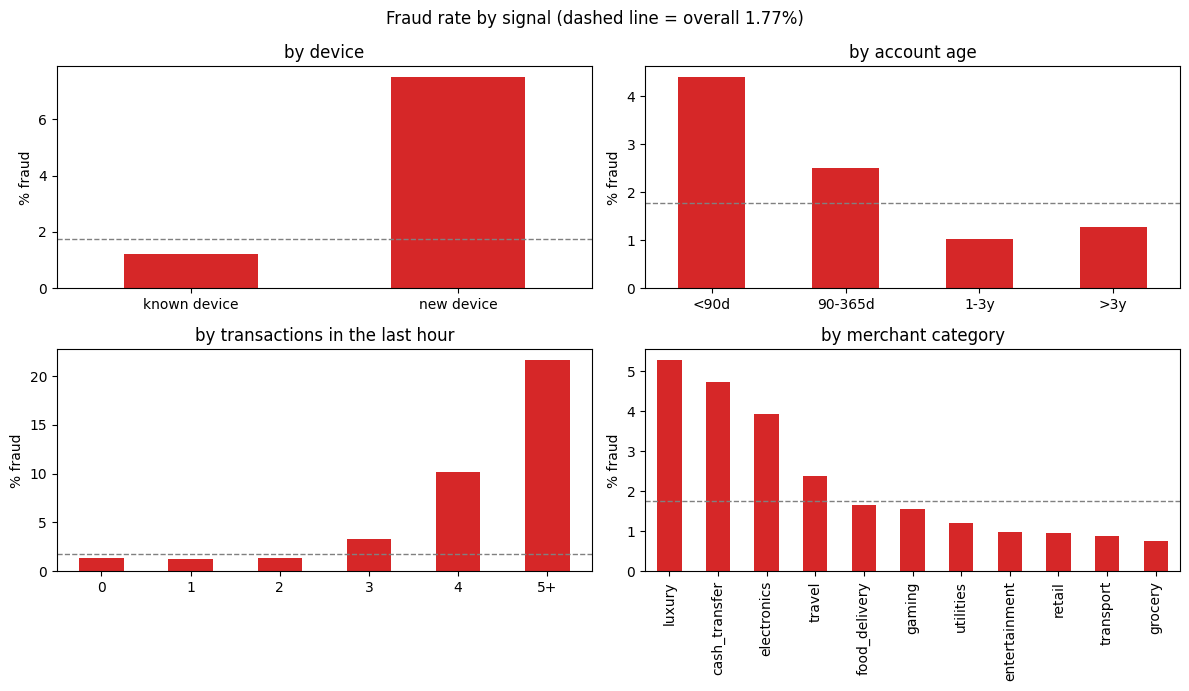

In [5]:
# 2b. What does fraud look like? Fraud rate by the four strongest signals.
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
base = 100 * train[TARGET].mean()

r = train.groupby("new_device")[TARGET].mean().mul(100)
r.index = ["known device", "new device"]
r.plot.bar(ax=axes[0, 0], color="C3", rot=0); axes[0, 0].set_title("by device")

age = pd.cut(train.account_age, [0, 90, 365, 1000, 4000], labels=["<90d", "90-365d", "1-3y", ">3y"])
train.groupby(age, observed=True)[TARGET].mean().mul(100).plot.bar(ax=axes[0, 1], color="C3", rot=0)
axes[0, 1].set_title("by account age")

r = train.groupby(train.transactions_last_1h.clip(upper=5))[TARGET].mean().mul(100)
r.index = ["0", "1", "2", "3", "4", "5+"]
r.plot.bar(ax=axes[1, 0], color="C3", rot=0); axes[1, 0].set_title("by transactions in the last hour")

train.groupby("merchant_category", observed=True)[TARGET].mean().mul(100).sort_values(ascending=False) \
     .plot.bar(ax=axes[1, 1], color="C3"); axes[1, 1].set_title("by merchant category")

for ax in axes.flat:
    ax.axhline(base, ls="--", c="gray", lw=1); ax.set_ylabel("% fraud"); ax.set_xlabel("")
plt.suptitle("Fraud rate by signal (dashed line = overall 1.77%)"); plt.tight_layout(); plt.show()
# Takeaway: fraud concentrates on new devices (7.5% vs 1.2%), young accounts (<90d: 4.5%), activity
# bursts (>=4 txns/hour: 16%+) and luxury/cash_transfer/electronics merchants - classic account-takeover shape.


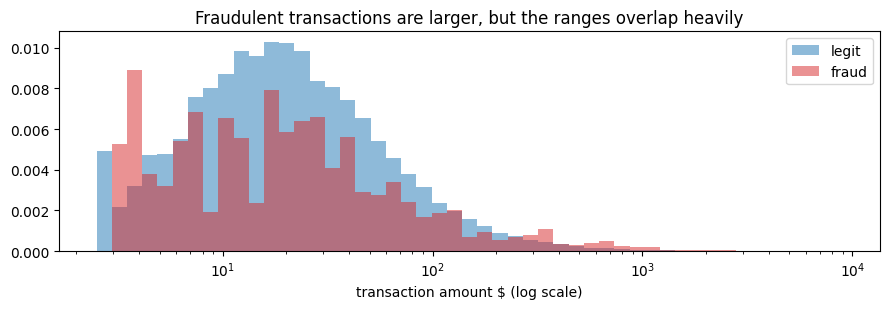

fraud   $: mean  570.81 | median  224.26
legit   $: mean  246.95 | median   74.26
fraud = 1.76% of transactions but 3.99% of dollars ($201,494.76)


In [6]:
# 2c. Is the money material? Amount distributions and dollar impact.
fr, lg = train[train[TARGET] == 1], train[train[TARGET] == 0]
fig, ax = plt.subplots(figsize=(9, 3.2))
bins = np.geomspace(2.5, 9000, 50)
ax.hist(lg.transaction_amount, bins=bins, density=True, alpha=.5, label="legit")
ax.hist(fr.transaction_amount, bins=bins, density=True, alpha=.5, color="C3", label="fraud")
ax.set_xscale("log"); ax.set_xlabel("transaction amount $ (log scale)"); ax.legend()
ax.set_title("Fraudulent transactions are larger, but the ranges overlap heavily")
plt.tight_layout(); plt.show()

print(f"fraud   $: mean {fr.transaction_amount.mean():7.2f} | median {fr.transaction_amount.median():7.2f}")
print(f"legit   $: mean {lg.transaction_amount.mean():7.2f} | median {lg.transaction_amount.median():7.2f}")
print(f"fraud = {train[TARGET].mean():.2%} of transactions but "
      f"{fr.transaction_amount.sum() / train.transaction_amount.sum():.2%} of dollars (${fr.transaction_amount.sum():,.2f})")
# Takeaway: the average fraud is ~2.3x the average legit transaction, so fraud is ~4% of dollars at
# 1.77% of volume - catching the expensive ones matters more than raw recall.


In [7]:
# 2d. How different is the test set? Profile shift + adversarial validation.
def prof(df):
    return pd.Series({
        "mean amount $": df.transaction_amount.mean(),
        "% amount > $2k": 100 * (df.transaction_amount > 2000).mean(),
        "% new device": 100 * df.new_device.mean(),
        "median account age (d)": df.account_age.median(),
        "avg % blanks per column": 100 * df[FEAT_COLS].isna().mean().mean(),
    })
display(pd.DataFrame({"train": prof(train), "test": prof(test)}).round(2))

# Adversarial validation: can a model tell train rows from test rows? AUC 0.5 = identical sets.
adv = pd.concat([train[FEAT_COLS], test[FEAT_COLS]], ignore_index=True)
for c in adv.select_dtypes("object"):
    adv[c] = adv[c].astype("category")
is_test = pd.Series(np.r_[np.zeros(len(train)), np.ones(len(test))])
aucs, p_adv = [], np.zeros(len(adv))
for tr_idx, va_idx in StratifiedKFold(3, shuffle=True, random_state=RANDOM_STATE).split(adv, is_test):
    m = lgb.LGBMClassifier(n_estimators=100, learning_rate=0.1, num_leaves=15,
                           random_state=RANDOM_STATE, verbose=-1).fit(adv.iloc[tr_idx], is_test.iloc[tr_idx])
    p_adv[va_idx] = m.predict_proba(adv.iloc[va_idx])[:, 1]
    aucs.append(roc_auc_score(is_test.iloc[va_idx], p_adv[va_idx]))
imp = pd.Series(m.feature_importances_, index=adv.columns).sort_values(ascending=False)
print(f"adversarial AUC: {np.mean(aucs):.3f} | top shift drivers: {', '.join(imp.index[:3])}")

# "Test-like" slice: the 20% of TRAIN rows that most resemble the test set - every model
# must also be checked on this slice, because the private set looks more like it.
adv_p_train = p_adv[:len(train)]
TEST_LIKE = adv_p_train >= np.quantile(adv_p_train, 0.80)
print(f"test-like slice: {TEST_LIKE.sum()} rows, {int(train.loc[TEST_LIKE, TARGET].sum())} frauds ({train.loc[TEST_LIKE, TARGET].mean():.2%})")
# Takeaway: the test set is visibly shifted (AUC ~0.67; driven by amount/age/device mix: bigger amounts,
# 15% new devices, more blanks) but not alien - so we optimise for robustness, not leaderboard quirks.


,train,test
mean amount $,252.66,523.93
% amount > $2k,2.27,9.03
% new device,9.06,15.37
median account age (d),790.00,1158.00
avg % blanks per column,0.52,1.81


adversarial AUC: 0.668 | top shift drivers: account_age, spend_last_24h, transaction_amount
test-like slice: 4000 rows, 136 frauds (3.40%)


In [8]:
# 2e. Where could the data mislead the model? Fraud rate when a column is blank.
rows = []
for c in FEAT_COLS:
    miss = train[c].isna()
    if miss.any():
        rows.append({"column": c, "blank_rows": int(miss.sum()),
                     "frauds_among_blanks": int(train.loc[miss, TARGET].sum()),
                     "fraud_%_blank": round(100 * train.loc[miss, TARGET].mean(), 2),
                     "fraud_%_present": round(100 * train.loc[~miss, TARGET].mean(), 2)})
pd.DataFrame(rows)
# Takeaway: blank merchant_category (0/113) and blank new_device (0/124) are NEVER fraud in train -
# an artefact, not a real pattern. Left alone, the model learns "blank => safe" and under-scores
# exactly the rows the test set has 3.5x more of. Section 3 neutralises this.


,column,blank_rows,frauds_among_blanks,fraud_%_blank,fraud_%_present
0,merchant_category,113,0,0.00,1.78
1,country,107,1,0.93,1.77
2,transaction_channel,123,4,3.25,1.76
3,transactions_last_24h,159,5,3.14,1.75
4,spend_last_24h,132,4,3.03,1.76
5,account_age,137,3,2.19,1.76
6,new_device,124,0,0.00,1.78
7,transactions_last_1h,142,4,2.82,1.76


## 3. Clean and preprocess the data
**Owner: Marcus.** Decisions, with reasons (each: *why → assumes → would break if*):

1. **Quality checks first** — no duplicate IDs/rows, hours all 0–23, amounts positive, `txns_1h ≤ txns_24h`
   everywhere. Nothing to repair. One documented quirk: 234 train / 762 test rows have `txns_24h == 1`
   but `spend_24h > 0` (the spend window seems to include the current transaction inconsistently).
   We don't "fix" it — later ratio features use `+1` guards instead.
2. **Impute every blank with a train-derived constant (median / mode), hard-coded below. No
   "was-missing" indicator flags.** *Why:* §2e shows train blanks encode an artificial "blank ⇒ never
   fraud" pattern, and the test set has ~3.5× more blanks — NaN-aware trees (or missing flags) would
   learn to wave through exactly the rows the private set is full of. Imputing makes a blank row look
   like a typical row, forcing the model to judge it on its remaining features. *Assumes:* blanks are
   recording gaps, not fraudster behaviour. *Breaks if:* blanks in the private set genuinely correlate
   with fraud — acceptable loss, that signal doesn't exist in train anyway.
3. **Category vocabularies fixed from train** (hard-coded) — deterministic, works on `test.csv` alone.
   A category never seen in train becomes `NaN` (LightGBM handles it natively) instead of crashing.
4. `id` is dropped — fraud rate is flat across ID ranges, it carries no signal.


In [9]:
# 3a. Quality checks - all must pass before we transform anything.
assert train[ID_COL].is_unique and test[ID_COL].is_unique
assert train.drop(columns=ID_COL).duplicated().sum() == 0
for df in (train, test):
    assert df.transaction_hour.between(0, 23).all()
    assert (df.transaction_amount > 0).all() and df.transaction_amount.notna().all()
    both = df[["transactions_last_1h", "transactions_last_24h"]].dropna()
    assert (both.transactions_last_1h <= both.transactions_last_24h).all()
quirk_tr = ((train.transactions_last_24h == 1) & (train.spend_last_24h > 0)).sum()
quirk_te = ((test.transactions_last_24h == 1) & (test.spend_last_24h > 0)).sum()
print(f"all quality checks passed | spend-definition quirk rows (txns_24h==1 & spend>0): train {quirk_tr}, test {quirk_te}")


all quality checks passed | spend-definition quirk rows (txns_24h==1 & spend>0): train 234, test 762


In [10]:
# 3b. clean(): impute with train constants (hard-coded so prediction.ipynb reproduces them
# without train.csv), then fix category vocabularies. Constants are verified against train below.
MERCHANTS = ["cash_transfer", "electronics", "entertainment", "food_delivery", "gaming",
             "grocery", "luxury", "retail", "transport", "travel", "utilities"]
COUNTRIES = ["AU", "GB", "ID", "JP", "MY", "PH", "SG", "TH", "US", "VN"]
CHANNELS  = ["bank_transfer", "card_present", "ecommerce", "mobile_app"]
CAT_VOCAB = {"merchant_category": MERCHANTS, "country": COUNTRIES, "transaction_channel": CHANNELS}
IMPUTE = {"transactions_last_24h": 4.0, "spend_last_24h": 217.515, "account_age": 790.0,
          "new_device": 0.0, "transactions_last_1h": 1.0,
          "merchant_category": "grocery", "country": "SG", "transaction_channel": "card_present"}

# Training ranges (min, max). Every numeric is clipped to its range so an out-of-range private-test
# value can neither crash the pipeline (a negative amount makes log1p NaN) nor be extrapolated by the
# linear model (transactions_last_24h = 100 would otherwise score 0.99). No training row is changed.
IMPUTE_AMOUNT, IMPUTE_HOUR = 75.125, 11                 # train medians, for the two never-blank columns
RANGES = {"transaction_amount": (2.5, 9000.0), "transaction_hour": (0, 23), "transactions_last_24h": (1, 27),
          "spend_last_24h": (0.0, 15670.31), "account_age": (5, 4000), "new_device": (0, 1), "transactions_last_1h": (0, 9)}

def clean(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for c, v in IMPUTE.items():                             # blanks -> typical value (see 3. above)
        out[c] = out[c].fillna(v)
    for c, vocab in CAT_VOCAB.items():
        out[c] = pd.Categorical(out[c], categories=vocab)   # unseen category -> NaN, never a crash
    return out

# Guard against drift: the hard-coded constants must equal what train actually says.
for c, v in IMPUTE.items():
    ref = train[c].mode()[0] if train[c].dtype == object else float(train[c].median())
    assert ref == v or abs(ref - v) < 1e-6, f"IMPUTE drift on {c}: train says {ref}, hard-coded {v}"
assert clean(train)[list(IMPUTE)].isna().sum().sum() == 0
assert clean(test)[list(IMPUTE)].isna().sum().sum() == 0
print("clean() OK - imputation constants match train; no blanks remain in either set")


clean() OK - imputation constants match train; no blanks remain in either set


## 4. Engineer useful features
`make_features(df)` must work on **test.csv alone** and match training exactly.

**Decision (revised after the model comparison):** our first pass tested 8 candidate features with
LightGBM and kept none — correctly, *for trees*: trees are invariant to monotone transforms and find
these interactions by splitting (§5b keeps that table as the lesson). But the model comparison
(docs/model_comparison_results.md) showed **logistic regression is half of the best shippable
model**, and for LR the engineered features ARE the gain (raw 0.213 → 0.229 PR-AUC): LR assumes
additive log-odds, so log transforms, interaction terms and threshold flags must be supplied
explicitly. `make_features` below is the team's v2 set (29 columns), inlined from `src/models.py`;
it applies the §3 imputation constants itself, so it still runs on the raw test file alone.
A category never seen in train becomes `"unknown"` → all-zero one-hot, never a crash.


In [11]:
RAW_FEATURES = ["transaction_amount", "transaction_hour", "merchant_category", "country",
                "transaction_channel", "transactions_last_24h", "spend_last_24h",
                "account_age", "new_device", "transactions_last_1h"]
NUMS = ["log_amount", "log_age", "log_spend", "transactions_last_1h", "transactions_last_24h",
        "transaction_hour", "amt_share_24h", "amt_vs_prev_avg", "log_amt_per_age", "burst_ratio",
        "log_amt_x_newdev", "log_amt_x_night", "hour_sin", "hour_cos", "spend_per_txn"]
FLAGS = ["new_device", "night", "amt_gt500", "age_lt180", "n1_ge3", "n1_ge4", "n24_ge10",
         "newdev_young", "big_old", "night_newdev", "burst_young"]
FEATURES = list(CAT_VOCAB) + NUMS + FLAGS         # 3 categoricals + 15 numerics + 11 flags = 29

def make_features(df: pd.DataFrame) -> pd.DataFrame:
    """v2 features (inlined from src/models.py). Runs on the raw test csv alone; never uses id."""
    d = df.copy()
    for c, v in IMPUTE.items():                       # blanks -> train constants (same policy as §3)
        d[c] = (pd.to_numeric(d[c], errors="coerce") if c not in CAT_VOCAB else d[c]).fillna(v)
    d["transaction_amount"] = pd.to_numeric(d["transaction_amount"], errors="coerce").fillna(IMPUTE_AMOUNT)
    d["transaction_hour"] = pd.to_numeric(d["transaction_hour"], errors="coerce").fillna(IMPUTE_HOUR)
    for c, (lo, hi) in RANGES.items():                 # out-of-range -> training range (see RANGES)
        d[c] = d[c].clip(lo, hi)
    for c in CAT_VOCAB:                               # unseen category -> "unknown": all-zero one-hot
        d[c] = d[c].where(d[c].isin(CAT_VOCAB[c]), "unknown")
    a, s, age = d.transaction_amount.astype(float), d.spend_last_24h, d.account_age
    n1, n24, nd, hr = d.transactions_last_1h, d.transactions_last_24h, d.new_device, d.transaction_hour
    X = d[list(CAT_VOCAB)].copy()
    X["log_amount"] = np.log1p(a)
    X["log_age"] = np.log1p(age)
    X["log_spend"] = np.log1p(s)
    X["transactions_last_1h"] = n1
    X["transactions_last_24h"] = n24
    X["transaction_hour"] = hr
    X["amt_share_24h"] = a / (a + s)                                        # this txn vs the day's spend
    X["amt_vs_prev_avg"] = np.log1p(a) - np.log1p(s / np.maximum(n24 - 1, 1))  # vs avg previous txn
    X["log_amt_per_age"] = np.log1p(a) - np.log1p(age)                      # big amount, young account
    X["burst_ratio"] = n1 / np.maximum(n24, 1)
    X["new_device"] = nd
    X["night"] = (hr <= 5).astype(float)
    X["amt_gt500"] = (a > 500).astype(float)                                # fraud 5-6% above $500
    X["age_lt180"] = (age < 180).astype(float)
    X["n1_ge3"] = (n1 >= 3).astype(float)
    X["n1_ge4"] = (n1 >= 4).astype(float)
    X["n24_ge10"] = (n24 >= 10).astype(float)
    X["newdev_young"] = nd * (age < 180)                                    # 17% fraud in train
    X["big_old"] = ((a > 500) & (age > 1000)).astype(float)                 # loyal big spender: NOT fraud
    X["log_amt_x_newdev"] = X["log_amount"] * nd
    X["log_amt_x_night"] = X["log_amount"] * X["night"]
    X["hour_sin"] = np.sin(2 * np.pi * hr / 24)
    X["hour_cos"] = np.cos(2 * np.pi * hr / 24)
    X["spend_per_txn"] = np.log1p(s / np.maximum(n24, 1))
    X["night_newdev"] = X["night"] * nd
    X["burst_young"] = X["n1_ge3"] * (age < 365).astype(float)
    return X[FEATURES]

y = train[TARGET]
X_raw = clean(train)[RAW_FEATURES]     # 10 raw columns - the §5 baseline and §5b lesson use these
X = make_features(train)               # v2 - everything from §6 on uses these
print(f"X_raw {X_raw.shape} | X {X.shape}")


X_raw (20000, 10) | X (20000, 29)


## 5. Build a baseline model
Two baselines: (a) naive — predict the base rate for everyone (PR-AUC floor = 0.0177, lift 1.0×);
(b) untuned LightGBM. **Protocol for every number in this notebook:** repeated stratified
**3×5-fold CV**, reported as per-fold mean ± std (353 positives → single-split numbers are noise),
plus PR-AUC **lift over the base rate** for the pitch. Pooled first-repeat OOF probabilities feed
the calibration/threshold analysis in §7.


In [12]:
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def fold_scores(model_fn, X, y, n_splits=5, n_repeats=3):
    """Per-fold PR-AUC over repeated stratified CV, plus pooled OOF probabilities (first repeat)."""
    rskf = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=RANDOM_STATE)
    aps, oof = [], np.zeros(len(y), dtype=float)
    for i, (tr_idx, va_idx) in enumerate(rskf.split(X, y)):
        m = model_fn()
        m.fit(X.iloc[tr_idx], y.iloc[tr_idx])
        p = m.predict_proba(X.iloc[va_idx])[:, 1]
        aps.append(average_precision_score(y.iloc[va_idx], p))
        if i < n_splits:
            oof[va_idx] = p
    return np.array(aps), oof

def evaluate(y_true, p, name=""):
    prec, rec, thr = precision_recall_curve(y_true, p)
    f1s = 2 * prec * rec / np.clip(prec + rec, 1e-9, None)
    k = int(np.nanargmax(f1s[:-1]))
    return {"model": name, "PR-AUC": round(average_precision_score(y_true, p), 4),
            "ROC-AUC": round(roc_auc_score(y_true, p), 4),
            "best_F1": round(float(f1s[k]), 4), "recall@bestF1": round(float(rec[k]), 4),
            "threshold@bestF1": round(float(thr[k]), 4),
            "Brier": round(brier_score_loss(y_true, p), 5)}

def lgbm_baseline():
    return lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=15,
                              random_state=RANDOM_STATE, verbose=-1)

BASE_RATE = y.mean()
naive = np.full(len(y), BASE_RATE)
aps_base, oof_base = fold_scores(lgbm_baseline, X_raw, y)
print(f"LightGBM baseline PR-AUC (3x5 CV): {aps_base.mean():.4f} ± {aps_base.std():.4f}"
      f"  = {aps_base.mean() / BASE_RATE:.1f}x lift over the {BASE_RATE:.4f} base rate")
pd.DataFrame([evaluate(y, naive, "naive (base rate)"),
              evaluate(y, oof_base, "LightGBM baseline (OOF)")])


LightGBM baseline PR-AUC (3x5 CV): 0.1952 ± 0.0448  = 11.1x lift over the 0.0176 base rate


,model,PR-AUC,ROC-AUC,best_F1,recall@bestF1,threshold@bestF1,Brier
0,naive (base rate),0.0176,0.5000,0.0347,1.0000,0.0176,0.01734
1,LightGBM baseline (OOF),0.1864,0.7362,0.2660,0.2125,0.1636,0.01571


### 5b. Do engineered features help *a tree*? Tested one at a time — none kept (and the lesson)
Keep-rule (decided with the team): a feature stays only if (1) its **paired** per-fold PR-AUC gain
beats 1 std, (2) it doesn't hurt the **test-like slice** (§2d), and (3) it doesn't raise adversarial
AUC (checked separately: max +0.003 across all candidates). Paired = same folds, difference per fold.


In [13]:
cl = clean(train)
CANDIDATES = {
    "is_night":           cl.transaction_hour.isin(range(6)).astype(int),
    "log_amount":         np.log1p(cl.transaction_amount),
    "amount_cents":       (cl.transaction_amount * 100 % 100).round(),
    "amount_per_spend24": cl.transaction_amount / (cl.spend_last_24h + 1),
    "amount_per_age":     cl.transaction_amount / (cl.account_age + 1),
    "burst_ratio":        cl.transactions_last_1h / cl.transactions_last_24h,
    "new_device_young":   (cl.new_device * (cl.account_age < 180)).astype(float),
    "spend_per_txn":      cl.spend_last_24h / cl.transactions_last_24h,
}
rows = []
for name, col in CANDIDATES.items():
    Xf = X_raw.copy(); Xf[name] = col
    aps_f, oof_f = fold_scores(lgbm_baseline, Xf, y)
    d = aps_f - aps_base
    d_slice = (average_precision_score(y[TEST_LIKE], oof_f[TEST_LIKE])
               - average_precision_score(y[TEST_LIKE], oof_base[TEST_LIKE]))
    rows.append({"feature": name, "dPR-AUC": round(d.mean(), 4), "std": round(d.std(), 4),
                 "d_test_like": round(d_slice, 4), "keep": bool(d.mean() > d.std() and d_slice >= -0.01)})
pd.DataFrame(rows)
# Takeaway: no candidate clears the bar FOR LIGHTGBM - log transforms are no-ops for trees and the
# ratios are splits it already finds. The lesson (see §4): the same features are a +0.016 PR-AUC gain
# for logistic regression, which needs them spelled out - test features per model family, not in general.


,feature,dPR-AUC,std,d_test_like,keep
0,is_night,-0.0018,0.0085,-0.0071,False
1,log_amount,0.0000,0.0000,0.0000,False
2,amount_cents,-0.0057,0.0178,-0.0163,False
3,amount_per_spend24,-0.0008,0.0184,-0.0000,False
4,amount_per_age,-0.0054,0.0127,0.0005,False
5,burst_ratio,-0.0030,0.0114,-0.0061,False
6,new_device_young,-0.0057,0.0131,-0.0133,False
7,spend_per_txn,-0.0028,0.0149,-0.0000,False


## 6. Train & compare models
**Owner: Germaine** — ~40 candidates compared in `notebooks/scratch_germaine.ipynb` on 5×5 shared
folds with corrected paired t-tests; full log in `docs/model_comparison_results.md`. Winners inlined
below. Key calls, each with its why:
- **LogisticRegression (C=0.2)**: assumes additive log-odds — the v2 features supply the
  interactions explicitly. Interpretable (exact per-row reason codes) and a top model outright.
- **LightGBM (shallow, one-hot)**: no functional-form assumptions; 353 positives can't support deep
  trees, so depth 3 / 7 leaves / heavy regularisation. One-hot beat native categorical splits
  (per-category stats overfit with this few positives).
- **50/50 soft-vote blend of the two** — fixed weights beat every tuned/stacked alternative, and tied LR in CV
  (+0.002, p = 0.72). **Shipped: LR alone** — on the public leaderboard LR scored 0.179 vs 0.169 for the blend
  (the only evidence from the test distribution), it needs only scikit-learn at inference, and it gives exact
  per-row reason codes. The blend is the documented runner-up (`docs/model_comparison_results.md`).
- **No class weights or resampling**: they inflate probabilities (Brier 0.023 vs 0.015) and this
  track scores probability quality. **No CatBoost**: better (0.2377) but not in
  `requirements-image.txt` — it cannot ship to the sandbox.


In [14]:
def logreg_v2():
    pre = ColumnTransformer([
        ("cat", OneHotEncoder(categories=[CAT_VOCAB[c] for c in CAT_VOCAB], handle_unknown="ignore"),
         list(CAT_VOCAB)),
        ("num", StandardScaler(), NUMS),
        ("flag", "passthrough", FLAGS)])
    return Pipeline([("pre", pre), ("clf", LogisticRegression(C=0.2, max_iter=5000))])

def lgbm_v2():
    pre = ColumnTransformer([("cat", OneHotEncoder(categories=[CAT_VOCAB[c] for c in CAT_VOCAB],
                                                   handle_unknown="ignore"), list(CAT_VOCAB))],
                            remainder="passthrough")
    return Pipeline([("pre", pre), ("clf", lgb.LGBMClassifier(
        n_estimators=600, learning_rate=0.03, num_leaves=7, max_depth=3, min_child_samples=80,
        reg_lambda=10.0, subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
        random_state=RANDOM_STATE, verbose=-1))])

def blend_lr_lgbm():
    return VotingClassifier([("lr", logreg_v2()), ("lgbm", lgbm_v2())], voting="soft")

candidates = {                      # name: (factory, feature matrix)
    "lgbm_baseline (10 raw)": (lgbm_baseline, X_raw),
    "logreg_v2 (SHIPPED)": (logreg_v2, X),
    "lgbm_v2": (lgbm_v2, X),
    "blend_lr_lgbm": (blend_lr_lgbm, X),
}
oof, rows = {}, []
for name, (fn, XX) in candidates.items():
    aps, o = fold_scores(fn, XX, y)
    oof[name] = o
    r = evaluate(y, o, name)                      # OOF-based F1/recall/Brier
    r["PR-AUC_3x5"] = f"{aps.mean():.4f}±{aps.std():.4f}"
    r["lift_vs_base_rate"] = f"{aps.mean() / BASE_RATE:.1f}x"
    rows.append(r)
pd.DataFrame(rows).sort_values("PR-AUC", ascending=False)


,model,PR-AUC,ROC-AUC,best_F1,recall@bestF1,threshold@bestF1,Brier,PR-AUC_3x5,lift_vs_base_rate
1,logreg_v2 (SHIPPED),0.2288,0.7866,0.2992,0.2691,0.1352,0.01514,0.2341±0.0365,13.3x
3,blend_lr_lgbm,0.2258,0.7785,0.2913,0.2125,0.2131,0.01515,0.2351±0.0380,13.3x
2,lgbm_v2,0.2109,0.7638,0.2840,0.1983,0.2519,0.01530,0.2231±0.0439,12.6x
0,lgbm_baseline (10 raw),0.1864,0.7362,0.2660,0.2125,0.1636,0.01571,0.1952±0.0448,11.1x


## 7. Evaluate performance
Beyond the headline metrics: calibration (do our probabilities mean what they say?), threshold choice in business terms, robustness to the known test shifts.


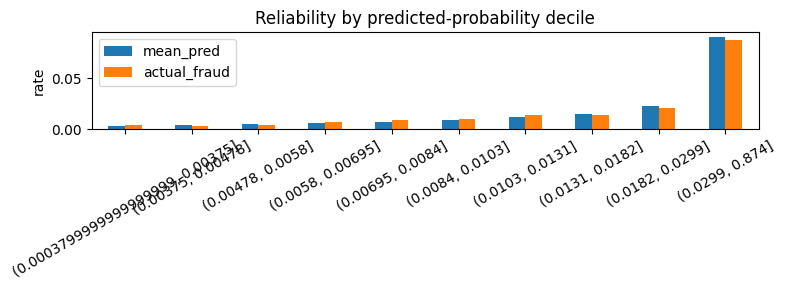

,threshold,%flagged,recall,F1,%fraud_$_caught,false_alarms_per_fraud_caught
0,0.02,17.57,0.586,0.107,84.3,16.0
1,0.05,4.65,0.397,0.218,62.6,5.6
2,0.10,1.99,0.292,0.274,48.9,2.9
3,0.20,0.88,0.207,0.277,34.7,1.4
4,0.30,0.55,0.173,0.264,32.6,0.8
5,0.50,0.30,0.119,0.203,25.8,0.4


In [15]:
BEST = "logreg_v2 (SHIPPED)"
p_best = oof[BEST]

# (a) Calibration: reliability curve + Brier (judging focus).
bins = pd.qcut(p_best, 10, duplicates="drop")
cal = pd.DataFrame({"mean_pred": pd.Series(p_best).groupby(bins, observed=True).mean(),
                    "actual_fraud": y.groupby(bins, observed=True).mean()})
ax = cal.plot(kind="bar", figsize=(8, 3), rot=30, title="Reliability by predicted-probability decile")
ax.set_ylabel("rate"); plt.tight_layout(); plt.show()
# Takeaway: bars should rise together; if class weights are used, recalibrate before trusting scores.

# (b) Business threshold: flag rate vs frauds caught vs fraud DOLLARS caught.
rows = []
for t in [0.02, 0.05, 0.10, 0.20, 0.30, 0.50]:
    flag = p_best >= t
    fraud_dollars = train.loc[(y == 1), "transaction_amount"]
    caught_dollars = train.loc[(y == 1) & flag, "transaction_amount"].sum() / fraud_dollars.sum()
    rows.append({"threshold": t, "%flagged": round(100 * flag.mean(), 2),
                 "recall": round(recall_score(y, flag), 3),
                 "F1": round(f1_score(y, flag), 3),
                 "%fraud_$_caught": round(100 * caught_dollars, 1),
                 "false_alarms_per_fraud_caught": round(((flag) & (y == 0)).sum() / max(1, ((flag) & (y == 1)).sum()), 1)})
pd.DataFrame(rows)


In [16]:
# (c) Robustness: inject extra blanks into the RAW data (the private test has ~3.5x more),
# run them through the full clean()+make_features pipeline, and score out-of-fold.
rng = np.random.default_rng(RANDOM_STATE)
test_blank = {c: test[c].isna().mean() for c in test.columns if c != ID_COL and test[c].isna().any()}
raw_holed = train.copy()
for c, rate in test_blank.items():                 # inject at the TEST's own per-column rates
    raw_holed.loc[rng.random(len(raw_holed)) < rate, c] = np.nan
X_holed = make_features(raw_holed)

oof_holed = np.zeros(len(y), dtype=float)
for tr_idx, va_idx in CV.split(X, y):
    m = logreg_v2().fit(X.iloc[tr_idx], y.iloc[tr_idx])       # shipped model, trained on clean folds
    oof_holed[va_idx] = m.predict_proba(X_holed.iloc[va_idx])[:, 1]  # score holed validation
print("PR-AUC out-of-fold — clean:", round(average_precision_score(y, p_best), 4),
      "| with extra blanks (imputed by clean()):", round(average_precision_score(y, oof_holed), 4))

# Blank-leak neutralised? Rows whose merchant_category/new_device was blank should score like anyone else.
was_blank = train.merchant_category.isna() | train.new_device.isna()
print(f"mean OOF probability — originally-blank rows: {p_best[was_blank].mean():.4f} "
      f"| all rows: {p_best.mean():.4f}  <- should be similar, NOT near zero")

big_old = (train.transaction_amount > 2000) & (train.account_age > 1000)
print(f"big+old slice (n={big_old.sum()}, fraud {train.loc[big_old, TARGET].mean():.1%}): "
      f"flagged at t=0.10: {(p_best[big_old] >= 0.10).mean():.1%}  <- keep this LOW (legit VIPs)")

# Test-like slice (top 20% adversarial P(test), defined in 2d): the private set looks more like
# these rows, so a model that only shines on typical train rows would flatter us here.
print(f"test-like slice (n={TEST_LIKE.sum()}, fraud {y[TEST_LIKE].mean():.2%}): "
      f"PR-AUC {average_precision_score(y[TEST_LIKE], p_best[TEST_LIKE]):.4f} "
      f"(lift {average_precision_score(y[TEST_LIKE], p_best[TEST_LIKE]) / y[TEST_LIKE].mean():.1f}x its base rate)")


PR-AUC out-of-fold — clean: 0.2288 | with extra blanks (imputed by clean()): 0.2219
mean OOF probability — originally-blank rows: 0.0109 | all rows: 0.0177  <- should be similar, NOT near zero
big+old slice (n=348, fraud 1.7%): flagged at t=0.10: 2.9%  <- keep this LOW (legit VIPs)
test-like slice (n=4000, fraud 3.40%): PR-AUC 0.4278 (lift 12.6x its base rate)


### 7b. Business impact: the cost-based alert policy *(Owner: Marcus)*
Metrics don't decide where to set the alert line — money does. **Cost model (adjustable
assumptions below):** a missed fraud (FN) costs the bank the full `transaction_amount`; every
alert (TP or FP) costs a fixed **review cost** — analyst time plus customer friction — default
**$5**, with sensitivity at $2 / $15; a caught fraud (TP) therefore saves its amount minus the
review cost. All computed on **repeated-CV out-of-fold probabilities** (an honest simulation of
unseen transactions — the test set is never touched).

The first sweep below exposes a trap we kept on purpose: the cost-optimal *probability*
threshold **loses to the dumb rule "flag everything over $500"**, because fraud dollars
concentrate in big transactions and a probability ranking ignores the dollars at stake. The fix
is to price each alert: **alert when expected loss (P(fraud) × amount) exceeds the review cost.**
That rule beats both. It is also **harder to game** than a pure amount rule — splitting one big
fraud into many small transactions drives the velocity features up and multiplies the fraudster's
exposure — though no static rule is immune to a patient adversary. And it needs exactly the
**calibrated probabilities** this track demands.


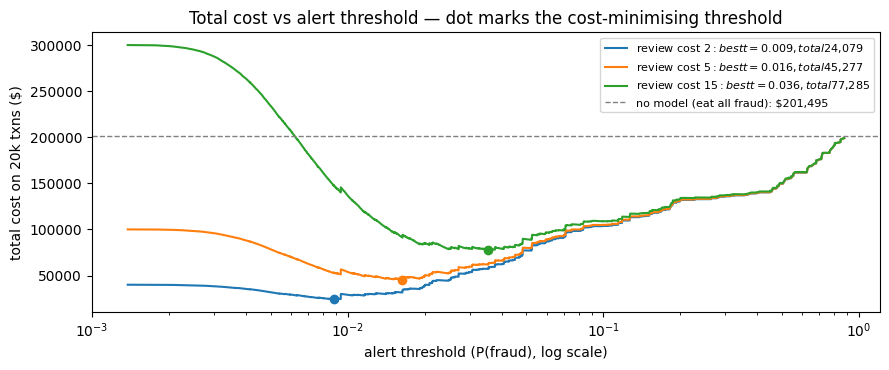

In [17]:
# Assumptions — adjust here and re-run.
REVIEW_COST = 5.0                      # $ per alert: analyst time + customer friction (OTP, call)
REVIEW_COST_SENSITIVITY = [2.0, 5.0, 15.0]

p_alert = p_best                       # OOF probabilities from §7 — never the test set
amt = train.transaction_amount.to_numpy()
is_fraud = y.to_numpy().astype(bool)
total_fraud_dollars = amt[is_fraud].sum()

# Sort transactions by score once; sweeping "alert on the top k" sweeps every threshold.
order = np.argsort(-p_alert)
amt_o, fraud_o, p_o = amt[order], is_fraud[order], p_alert[order]
caught_dollars_cum = np.cumsum(np.where(fraud_o, amt_o, 0.0))
caught_count_cum = np.cumsum(fraud_o)
k = np.arange(1, len(p_o) + 1)

fig, ax = plt.subplots(figsize=(9, 3.8))
best = {}
for c in REVIEW_COST_SENSITIVITY:
    cost = (total_fraud_dollars - caught_dollars_cum) + c * k   # missed fraud $ + review bill
    i = int(np.argmin(cost))
    best[c] = {"t": float(p_o[i]), "cost": float(cost[i]), "k": int(i + 1)}
    ax.plot(p_o, cost, label=f"review cost ${c:.0f}: best t={p_o[i]:.3f}, total ${cost[i]:,.0f}")
    ax.scatter([p_o[i]], [cost[i]], zorder=5)
ax.axhline(total_fraud_dollars, ls="--", c="gray", lw=1,
           label=f"no model (eat all fraud): ${total_fraud_dollars:,.0f}")
ax.set_xscale("log"); ax.set_xlabel("alert threshold (P(fraud), log scale)")
ax.set_ylabel("total cost on 20k txns ($)"); ax.legend(fontsize=8)
ax.set_title("Total cost vs alert threshold — dot marks the cost-minimising threshold")
plt.tight_layout(); plt.savefig("business_impact_chart.png", dpi=150, bbox_inches="tight"); plt.show()
# Takeaway: the optimum moves with the review cost - cheap reviews push the threshold down
# (alert more); expensive reviews push it up. We present the $5 optimum and show both neighbours.


,model,policy,%flagged,fraud_cases,fraud_$,saved_per_10k
0,-,no model,0.00%,0.0%,0.0%,0
1,-,rule: amount > $500,10.64%,34.3%,84.9%,80200
2,baseline LGBM (10 raw),p-threshold optimum (t=0.010),26.19%,62.9%,86.8%,74396
3,baseline LGBM (10 raw),p x amount > $5,14.31%,51.6%,87.1%,80613
4,shipped LR,p-threshold optimum (t=0.016),22.88%,64.6%,88.9%,78109
5,shipped LR,p x amount > $5,17.01%,55.8%,92.1%,84309


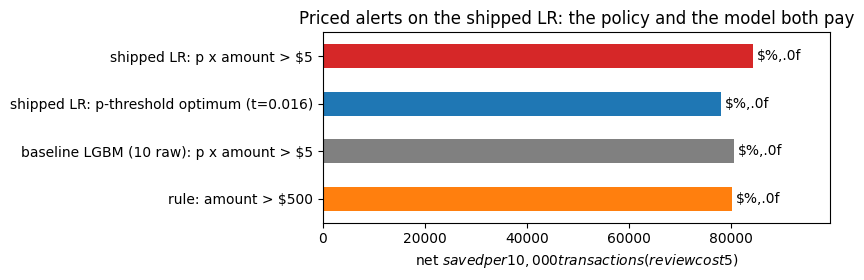

operating policy (shipped LR): alert when p x amount > $5
  flags 17.01% | catches 55.8% of cases, 92.1% of fraud dollars (dollars > cases: big frauds are caught preferentially, by design)
  review cost $   2: flags 28.69%, saves $91,659/10k
  review cost $   5: flags 17.01%, saves $84,309/10k
  review cost $  15: flags  9.56%, saves $70,450/10k


,review_capacity,alerts_per_10k,fraud_cases_caught,fraud_dollars_caught
0,top 1% by p x amount,100,14.7%,49.5%
1,top 2% by p x amount,200,17.3%,52.8%
2,top 5% by p x amount,500,27.8%,75.2%


In [18]:
c = REVIEW_COST

def policy_rows(p, label):
    """The three policies for a given model's OOF probabilities, at review cost c."""
    el = p * amt
    o = np.argsort(-p); kk = np.arange(1, len(p) + 1)
    cost = (total_fraud_dollars - np.cumsum(np.where(is_fraud[o], amt[o], 0.0))) + c * kk
    t_opt = float(p[o][int(np.argmin(cost))])
    def row(name, flag):
        saved = amt[flag & is_fraud].sum() - c * flag.sum()
        return {"model": label, "policy": name, "%flagged": f"{flag.mean():.2%}",
                "fraud_cases": f"{is_fraud[flag].sum() / is_fraud.sum():.1%}",
                "fraud_$": f"{amt[flag & is_fraud].sum() / total_fraud_dollars:.1%}",
                "saved_per_10k": round(saved * 10_000 / len(train))}
    return [row(f"p-threshold optimum (t={t_opt:.3f})", p >= t_opt),
            row(f"p x amount > ${c:.0f}", el > c)]

rule = amt > 500
policies = pd.DataFrame(
    [{"model": "-", "policy": "no model", "%flagged": "0.00%", "fraud_cases": "0.0%",
      "fraud_$": "0.0%", "saved_per_10k": 0},
     {"model": "-", "policy": "rule: amount > $500", "%flagged": f"{rule.mean():.2%}",
      "fraud_cases": f"{is_fraud[rule].sum() / is_fraud.sum():.1%}",
      "fraud_$": f"{amt[rule & is_fraud].sum() / total_fraud_dollars:.1%}",
      "saved_per_10k": round((amt[rule & is_fraud].sum() - c * rule.sum()) * 10_000 / len(train))}]
    + policy_rows(oof_base, "baseline LGBM (10 raw)")
    + policy_rows(p_best, "shipped LR"))
display(policies)

sel = policies.iloc[[1, 3, 4, 5]].set_index(policies.iloc[[1, 3, 4, 5]].apply(
    lambda r: f"{r.model}: {r.policy}" if r.model != "-" else r.policy, axis=1))
ax = sel.saved_per_10k.plot.barh(figsize=(8.5, 2.9), color=["C1", "gray", "C0", "C3"])
ax.set_xlabel("net $ saved per 10,000 transactions (review cost $5)")
ax.set_title("Priced alerts on the shipped LR: the policy and the model both pay")
ax.bar_label(ax.containers[0], fmt="$%,.0f", padding=3); ax.margins(x=0.18)
plt.tight_layout(); plt.savefig("business_impact_chart.png", dpi=150, bbox_inches="tight"); plt.show()

exp_loss = p_best * amt
flag = exp_loss > c
print(f"operating policy (shipped LR): alert when p x amount > ${c:.0f}")
print(f"  flags {flag.mean():.2%} | catches {is_fraud[flag].sum()/is_fraud.sum():.1%} of cases, "
      f"{amt[flag & is_fraud].sum()/total_fraud_dollars:.1%} of fraud dollars "
      f"(dollars > cases: big frauds are caught preferentially, by design)")
for cs in REVIEW_COST_SENSITIVITY:
    fl = exp_loss > cs
    sv = amt[fl & is_fraud].sum() - cs * fl.sum()
    print(f"  review cost ${cs:>4.0f}: flags {fl.mean():6.2%}, saves ${sv * 10_000 / len(train):,.0f}/10k")

# Review-capacity view: if the fraud team can only review the top X%, ranked by expected loss.
order_el = np.argsort(-exp_loss)
cum_d = np.cumsum(np.where(is_fraud[order_el], amt[order_el], 0.0))
cum_n = np.cumsum(is_fraud[order_el])
rows = []
for frac in [0.01, 0.02, 0.05]:
    kk = int(round(frac * len(amt)))
    rows.append({"review_capacity": f"top {frac:.0%} by p x amount", "alerts_per_10k": int(round(kk * 10_000 / len(train))),
                 "fraud_cases_caught": f"{cum_n[kk-1] / is_fraud.sum():.1%}",
                 "fraud_dollars_caught": f"{cum_d[kk-1] / total_fraud_dollars:.1%}"})
pd.DataFrame(rows)


In [19]:
# Calibration check for the priced-alert rule: p x amount is an EXPECTED loss, so the policy
# is only as good as the probabilities are honest.
bins = pd.qcut(p_best, 10, duplicates="drop")
cal = pd.DataFrame({"mean_p": pd.Series(p_best).groupby(bins, observed=True).mean(),
                    "actual_fraud": y.groupby(bins, observed=True).mean()})
gap = float((cal.mean_p - cal.actual_fraud).abs().max())
print(f"shipped LR OOF: Brier {brier_score_loss(y, p_best):.5f} (naive {brier_score_loss(y, naive):.5f}) "
      f"| max decile |mean_p - actual| = {gap:.4f}")
# NOTE(Germaine): if any future candidate uses class weights or resampling, recalibrate on OOF
# (Platt/isotonic) BEFORE it feeds this section - otherwise p x amount misprices every alert.
# The shipped LR needs none: no weights, reliability curve ~ diagonal (§7a), and isotonic
# recalibration made Brier worse in your 5x5 runs, so it is correctly NOT applied.


shipped LR OOF: Brier 0.01514 (naive 0.01734) | max decile |mean_p - actual| = 0.0033


## 8. Explainability *(supports the 40% understanding mark)*
TODO: SHAP global importance + walk through one flagged transaction (top-3 reasons in plain English). Prototype in scratch notebooks with `src/explain.py`, then inline.


## 9. Save the model — `model.pkl`
The shipped model is the **logistic-regression pipeline on the 29 v2 features** (the LR + LightGBM blend tied it in CV and
scored lower on the public leaderboard; see §6). It is **standard sklearn classes only**, so the pickle loads in the organisers' sandbox with no custom code, *provided it is
trained under the platform's library versions* (`.venv-image` from `requirements-image.txt`).
The prediction notebook reads probabilities via `predict_proba` (with a `predict` fallback for
booster-style models), exactly like the organisers' own template notebook.


In [20]:
final_model = logreg_v2().fit(X, y)                 # shipped: LR on the 29 v2 features (blend = runner-up)
joblib.dump((final_model, FEATURES), "model.pkl")

# Verify exactly as prediction.ipynb will consume it:
loaded, feats = joblib.load("model.pkl")
Xt = make_features(test)[feats]
check = loaded.predict_proba(Xt)[:, 1] if hasattr(loaded, "predict_proba") else loaded.predict(Xt)
assert len(check) == len(test) and 0 <= check.min() <= check.max() <= 1
print("model.pkl OK — probabilities:", np.round(check[:5], 4))


model.pkl OK — probabilities: [0.0055 0.0137 0.007  0.008  0.0042]


## 10. Generate the leaderboard CSV (`id,prediction`)
The portal's public leaderboard scores CSVs with columns **`id,prediction`**, matching `sample_submission.csv`
(verified 3 Oct: same 12,000 IDs, same row order as `test.csv`). This cell writes that file and, when
`sample_submission.csv` is nearby, diffs IDs against it before we ever upload.


In [21]:
model, features = joblib.load("model.pkl")
test_df = pd.read_csv(TEST_PATH)
X_test = make_features(test_df)[features]
preds = (model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba")
         else model.predict(X_test))

sub = pd.DataFrame({"id": test_df[ID_COL], "prediction": preds})
sub.to_csv("submission.csv", index=False)
assert list(sub.columns) == ["id", "prediction"]
assert len(sub) == len(test_df) and sub.id.str.fullmatch(r"FR\d{6}").all()
assert 0 <= sub.prediction.min() <= sub.prediction.max() <= 1

sample = find_csv(["sample_submission.csv"], required=False)  # official template, only if present
if sample is not None:
    s = pd.read_csv(sample)
    if list(s.columns) == list(sub.columns) and (s.id.values == sub.id.values).all():
        print("matches sample_submission.csv: columns and row order OK")
    else:
        print("WARNING: format differs from sample_submission.csv - check before uploading")
else:
    print("sample_submission.csv not found - skipped the optional format check")
print(f"wrote submission.csv: {len(sub)} rows, mean p {preds.mean():.4f}")
sub.head(3)


sample_submission.csv not found - skipped the optional format check
wrote submission.csv: 12000 rows, mean p 0.0216


,id,prediction
0,FR021005,0.005495
1,FR030078,0.013705
2,FR020717,0.006970


### Upload package (separate from this notebook)
`notebooks/prediction.ipynb` is the file we upload: it only loads `model.pkl` and predicts — **no training cells**. It inlines `clean`/`make_features`/vocab constants, which must stay byte-identical to §3–4 here. In the sandbox the test file has **no `id` column** and rows are shuffled; the notebook writes one `prediction` per row (same order) to `DATATHON_OUTPUT_PATH`. The sandbox uses the platform's own library versions, so **run this notebook with the repo's `.venv-image` kernel (built from `requirements-image.txt`) whenever producing the real `model.pkl`**, or the pickle may not load there.


## 11. Limitations and next steps
- Only 353 fraud examples → fold-to-fold variance; we report mean ± spread, not single numbers.
- ~1 in 6 frauds (62/353) show no observable signal → hard recall ceiling; honest in the report.
- No customer ID or timestamps → no per-customer behaviour baselines (biggest real-world gap).
- 48% of frauds are non-SG vs 30% of legit → model flags foreign customers more; a bank must monitor fairness.
- Next: customer history, periodic retraining, calibration monitoring ("does 30% still mean 30%?").
